<a href="https://colab.research.google.com/github/isuarez26/Analisis_de_Datos_2026/blob/main/Presentaci%C3%B3nCodigo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análisis de factores asociados al rendimiento académico y bienestar estudiantil

1. Definición del problema

En el entorno universitario, el desempeño académico no depende únicamente de la capacidad intelectual del estudiante, sino también de factores conductuales, emocionales y de estilo de vida. Variables como el sueño, el tiempo de estudio, el uso de redes sociales, la actividad física y el nivel de estrés pueden influir de manera significativa tanto en el rendimiento académico como en la salud mental de la población estudiantil.

El problema que se busca resolver consiste en identificar qué factores del estilo de vida están más asociados con un bajo desempeño académico y con la presencia de depresión en estudiantes, con el fin de generar evidencia útil para la toma de decisiones institucionales. Esta necesidad es relevante porque permite pasar de una gestión reactiva a una gestión preventiva, orientada a la detección temprana de patrones de riesgo.

El análisis se ubica en un contexto empresarial-institucional de gestión educativa y bienestar organizacional, particularmente en universidades o instituciones de educación superior que buscan mejorar la retención estudiantil, fortalecer el rendimiento académico y diseñar programas de apoyo psicoeducativo basados en datos.

2. Preguntas de investigación

El proyecto buscará responder las siguientes preguntas estratégicas:

¿Qué variables del estilo de vida presentan una relación más fuerte con el CGPA de los estudiantes?

¿Qué factores están más asociados con un mayor nivel de estrés y con la presencia de depresión?

¿Existen diferencias relevantes en rendimiento académico y bienestar según género, edad o departamento académico?

¿El sueño, la actividad física y el tiempo de estudio funcionan como factores protectores frente a la depresión?

¿El uso elevado de redes sociales se asocia con peores resultados académicos o emocionales?

¿Es posible identificar perfiles de estudiantes con mayor probabilidad de presentar riesgo académico o emocional?


Hipótesis de trabajo

A partir de estas preguntas, se plantean las siguientes hipótesis preliminares:

H1: A mayor nivel de estrés, mayor probabilidad de depresión.

H2: Menores horas de sueño se asocian con peor desempeño académico.

H3: Mayor tiempo de estudio se relaciona positivamente con un mejor CGPA.

H4: Mayor actividad física se relaciona con menor nivel de estrés.

H5: Existen diferencias significativas entre departamentos académicos en cuanto a rendimiento y bienestar estudiantil.

3. Alcance del proyecto

Incluye:

Análisis descriptivo de la población estudiantil contenida en la base de datos.
Exploración de relaciones entre variables académicas, conductuales y de salud mental.

Identificación de patrones, tendencias y posibles factores de riesgo.
Segmentación de estudiantes con base en combinaciones de variables relevantes.
Evaluación de asociaciones entre CGPA, estrés, sueño, actividad física, redes sociales y depresión.

Generación de hallazgos orientados a apoyar decisiones institucionales.

Queda fuera del alcance:

Diagnóstico clínico de depresión.

Diseño e implementación de intervenciones psicológicas o médicas.

Otras variables que resulten determinantes para el bienestar de la comunidad estudiantil.

4. Impacto potencial

Este proyecto puede generar un valor significativo para la institución al proporcionar una base empírica para la toma de decisiones. En particular, los resultados podrían:

Permitir la identificación temprana de estudiantes en situación de riesgo académico o emocional.

Apoyar el diseño de programas de prevención, orientación y acompañamiento estudiantil.

Mejorar la asignación de recursos en áreas de tutoría, bienestar universitario y apoyo psicológico.

5. Objetivo general

Analizar la relación entre hábitos de vida, desempeño académico y bienestar emocional de los estudiantes con el fin de identificar factores asociados a bajo rendimiento y riesgo de depresión, y así proporcionar insumos útiles para la toma de decisiones institucionales.

6. Entregable esperado

Como resultado del proyecto, se espera contar con un análisis estructurado que incluya hallazgos clave, perfiles de riesgo y recomendaciones estratégicas dirigidas al comité directivo o a las áreas responsables de bienestar estudiantil y gestión académica.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1) CARGA Y LIMPIEZA
# =========================
df = pd.read_excel("student_lifestyle_100k.xlsx")

# Limpieza básica
df.columns = df.columns.str.strip()
df = df.drop_duplicates()
df = df.dropna()

# Asegurar tipo booleano en depresión
df["Depression"] = df["Depression"].astype(bool)

# Variable auxiliar para correlaciones
df["Depression_num"] = df["Depression"].astype(int)

# Resumen rápido de limpieza
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("Valores faltantes:", df.isna().sum().sum())
print("Duplicados:", df.duplicated().sum())
print("Tasa de depresión:", round(df["Depression"].mean() * 100, 2), "%")

Filas: 100000
Columnas: 12
Valores faltantes: 0
Duplicados: 0
Tasa de depresión: 10.06 %


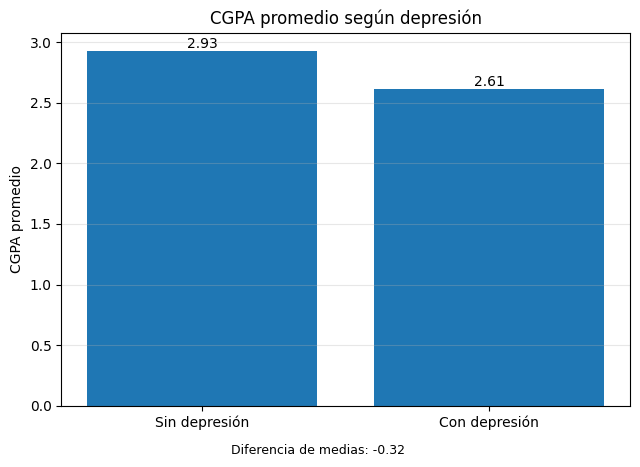

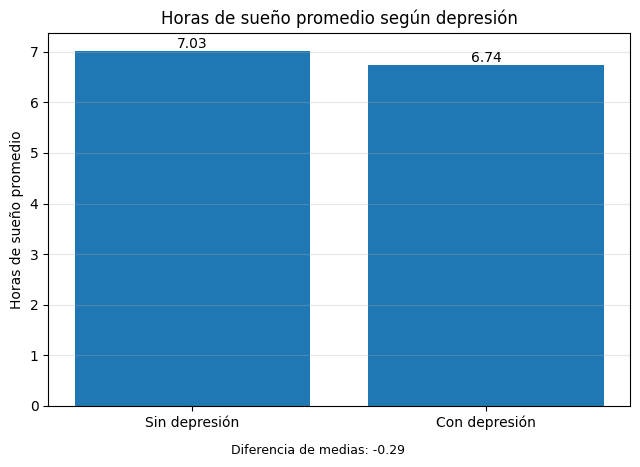

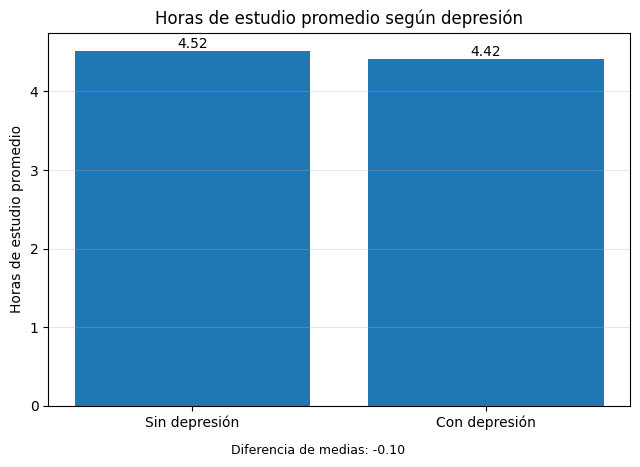

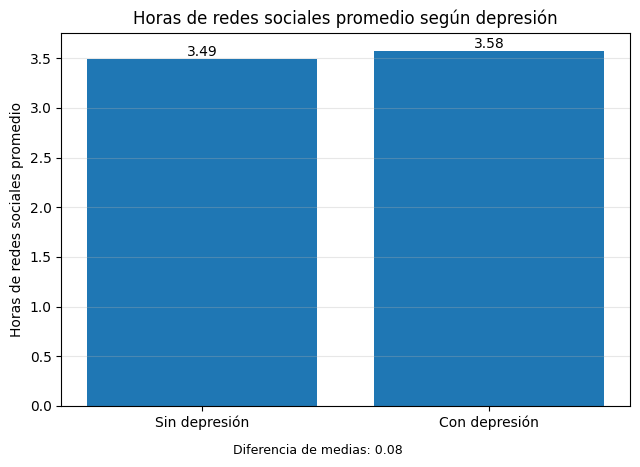

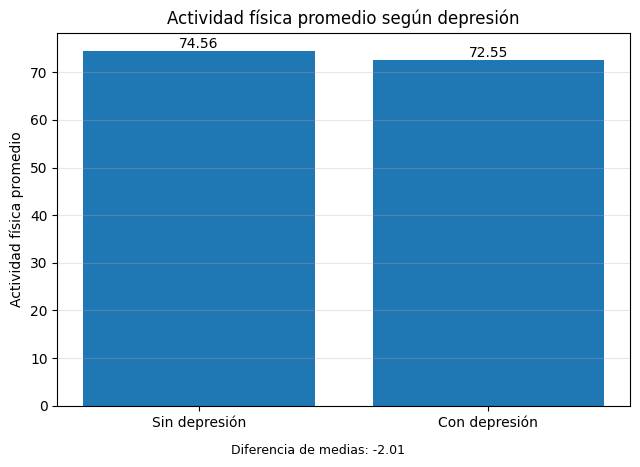

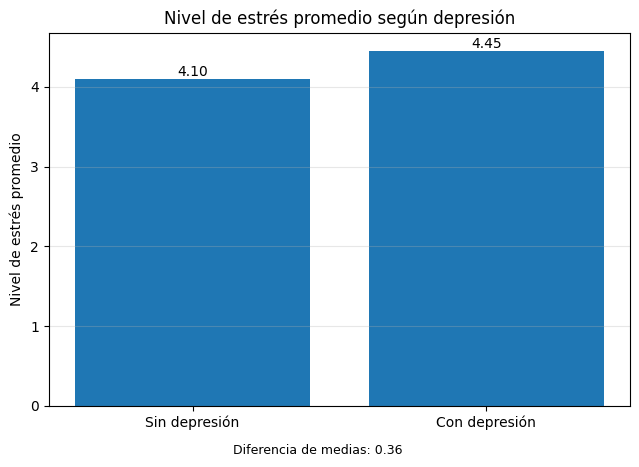

In [ ]:
# =========================
# VARIABLES DE RIESGO / PROTECCIÓN
# =========================
risk_vars = {
    "CGPA": "CGPA promedio",
    "Sleep_Duration": "Horas de sueño promedio",
    "Study_Hours": "Horas de estudio promedio",
    "Social_Media_Hours": "Horas de redes sociales promedio",
    "Physical_Activity": "Actividad física promedio",
    "Stress_Level": "Nivel de estrés promedio"
}

# =========================
# FUNCIÓN PARA GRAFICAR
# =========================
def plot_risk_variable(df, var, title):
    mean_no = df.loc[~df["Depression"], var].mean()
    mean_yes = df.loc[df["Depression"], var].mean()

    values = [mean_no, mean_yes]
    labels = ["Sin depresión", "Con depresión"]

    plt.figure(figsize=(6.5, 4.5))
    bars = plt.bar(labels, values)

    plt.title(f"{title} según depresión")
    plt.ylabel(title)
    plt.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            val,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    # Prueba estadística opcional para respaldar el hallazgo
    a = df.loc[~df["Depression"], var]
    b = df.loc[df["Depression"], var]
    t, p = stats.ttest_ind(a, b, equal_var=False)

    plt.figtext(
        0.5, -0.02,
        f"Diferencia de medias: {mean_yes - mean_no:.2f} ",
        ha="center",
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

# =========================
# GRAFICAR SOLO VARIABLES RELEVANTES
# =========================
for var, title in risk_vars.items():
    plot_risk_variable(df, var, title)


=== Variables categóricas y su relación con CGPA ===
  Variable      F_stat  p_value  eta_squared
Depression 3308.992437 0.000000     0.032031
    Gender    2.665525 0.102547     0.000027
Department    0.466895 0.760098     0.000019

=== Variables numéricas y su relación con CGPA ===
          Variable  pearson_r    abs_r       p_value
       Study_Hours   0.099534 0.099534 1.609291e-218
Social_Media_Hours  -0.087998 0.087998 4.516631e-171
    Sleep_Duration   0.015386 0.015386  1.139693e-06
      Stress_Level  -0.012287 0.012287  1.020279e-04
 Physical_Activity   0.004766 0.004766  1.317975e-01
               Age   0.003248 0.003248  3.043162e-01

=== Ranking general de variables asociadas a CGPA ===
          Variable  Métrica_influencia       Tipo
       Study_Hours            0.099534   Numérica
Social_Media_Hours            0.087998   Numérica
        Depression            0.032031 Categórica
    Sleep_Duration            0.015386   Numérica
      Stress_Level            0.012287

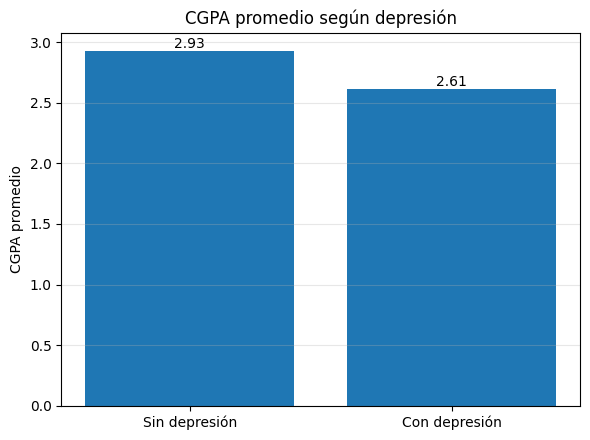

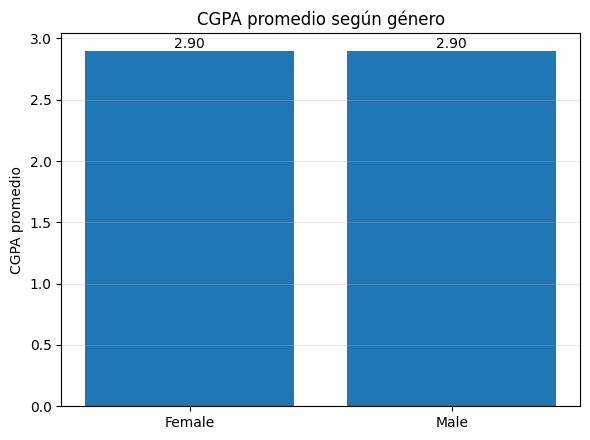

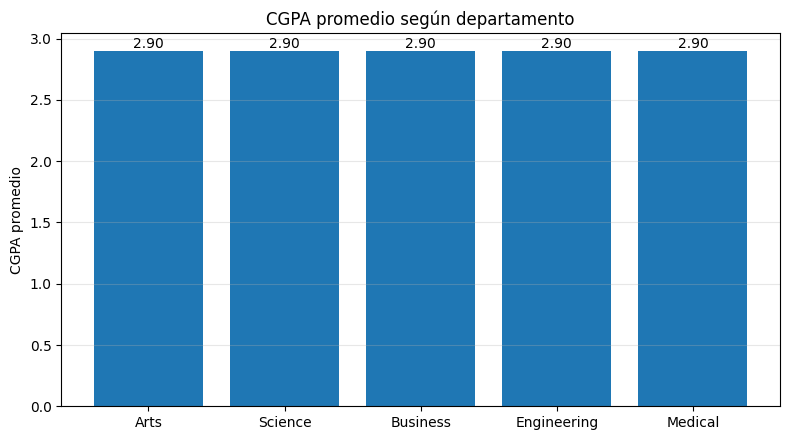

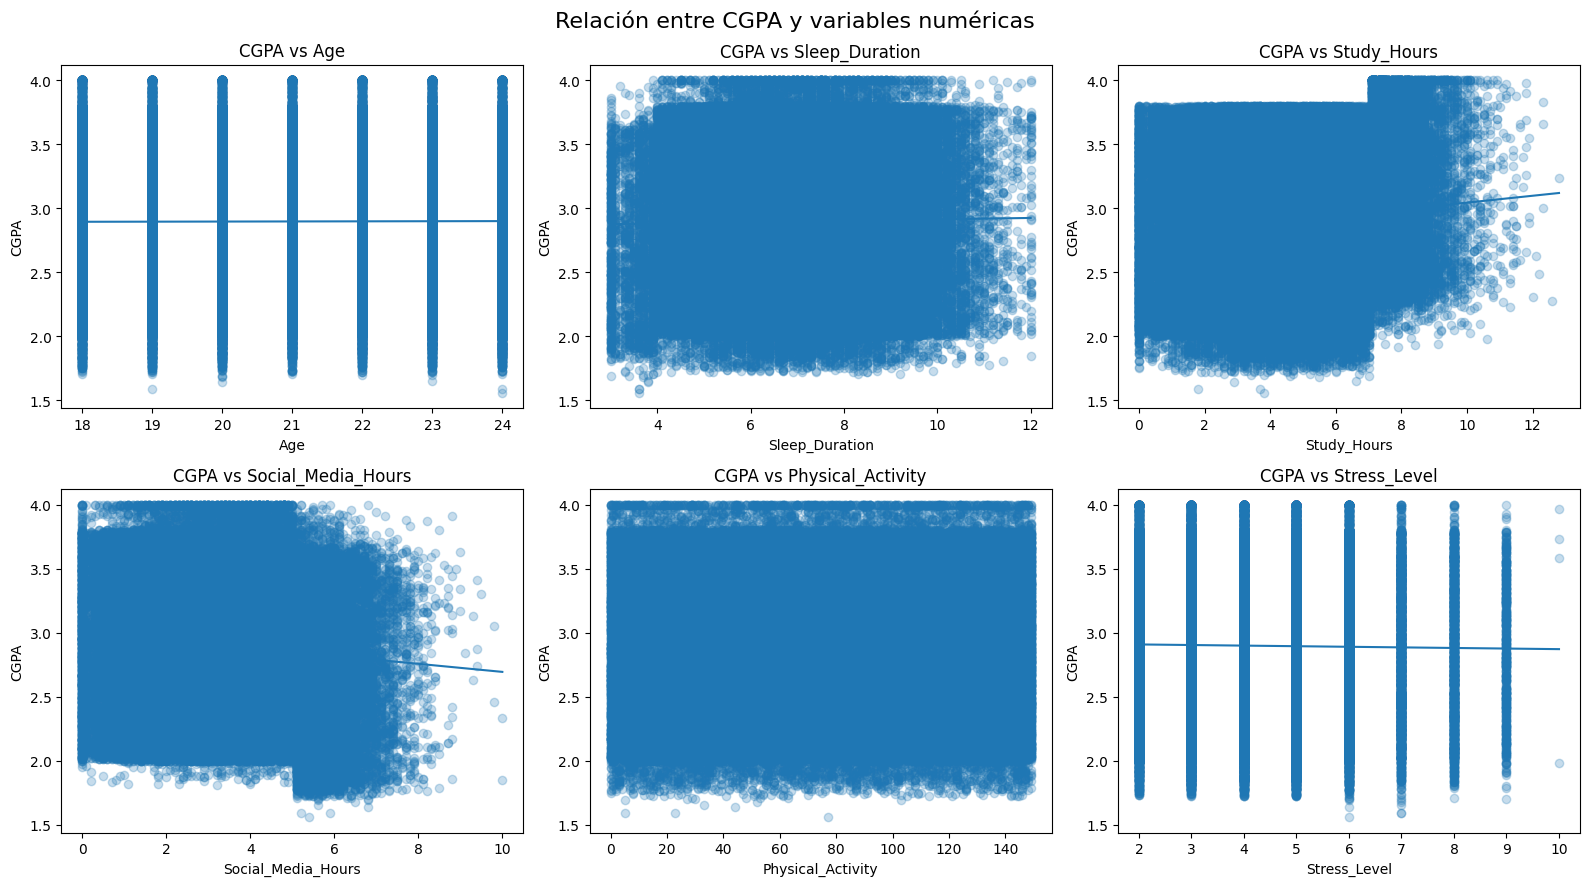


=== Interpretación rápida ===
Variables categóricas con mayor capacidad explicativa sobre CGPA:
  Variable  eta_squared
Depression     0.032031
    Gender     0.000027
Department     0.000019

Variables numéricas con mayor correlación absoluta con CGPA:
          Variable  pearson_r
       Study_Hours   0.099534
Social_Media_Hours  -0.087998
    Sleep_Duration   0.015386
      Stress_Level  -0.012287
 Physical_Activity   0.004766
               Age   0.003248


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1) CARGA Y LIMPIEZA (moved from cell 51OejT6Us3p8)
# =========================
df = pd.read_excel("student_lifestyle_100k.xlsx")

# Limpieza básica
df.columns = df.columns.str.strip()
df = df.drop_duplicates()
df = df.dropna()

# Asegurar tipo booleano en depresión
df["Depression"] = df["Depression"].astype(bool)

# Variable auxiliar para correlaciones
df["Depression_num"] = df["Depression"].astype(int)

# =========================
# 2) VARIABLES A ANALIZAR
# =========================
target = "CGPA"

numeric_vars = [
    "Age",
    "Sleep_Duration",
    "Study_Hours",
    "Social_Media_Hours",
    "Physical_Activity",
    "Stress_Level"
]

categorical_vars = [
    "Gender",
    "Department",
    "Depression"
]

# =========================
# 3) COMPARACIÓN DE CGPA VS VARIABLES CATEGÓRICAS
# =========================
def eta_squared_anova(df, cat_var, num_var="CGPA"):
    groups = [g[num_var].values for _, g in df.groupby(cat_var)]
    f_stat, p_val = stats.f_oneway(*groups)
    grand_mean = df[num_var].mean()
    ss_between = sum(len(g) * (g[num_var].mean() - grand_mean) ** 2 for _, g in df.groupby(cat_var))
    ss_total = sum((df[num_var] - grand_mean) ** 2)
    eta2 = ss_between / ss_total if ss_total != 0 else np.nan
    return f_stat, p_val, eta2

cat_results = []
for var in categorical_vars:
    f_stat, p_val, eta2 = eta_squared_anova(df, var, target)
    cat_results.append([var, f_stat, p_val, eta2])

cat_results_df = pd.DataFrame(
    cat_results,
    columns=["Variable", "F_stat", "p_value", "eta_squared"]
).sort_values("eta_squared", ascending=False)

print("\n=== Variables categóricas y su relación con CGPA ===")
print(cat_results_df.to_string(index=False))

# =========================
# 4) COMPARACIÓN DE CGPA VS VARIABLES NUMÉRICAS
# =========================
num_results = []
for var in numeric_vars:
    r, p_val = stats.pearsonr(df[var], df[target])
    num_results.append([var, r, abs(r), p_val])

num_results_df = pd.DataFrame(
    num_results,
    columns=["Variable", "pearson_r", "abs_r", "p_value"]
).sort_values("abs_r", ascending=False)

print("\n=== Variables numéricas y su relación con CGPA ===")
print(num_results_df.to_string(index=False))

# =========================
# 5) TABLA FINAL DE INFLUENCIA SOBRE CGPA
# =========================
cat_rank = cat_results_df[["Variable", "eta_squared"]].copy()
cat_rank["Tipo"] = "Categórica"
cat_rank = cat_rank.rename(columns={"eta_squared": "Métrica_influencia"})

num_rank = num_results_df[["Variable", "abs_r"]].copy()
num_rank["Tipo"] = "Numérica"
num_rank = num_rank.rename(columns={"abs_r": "Métrica_influencia"})

influence_df = pd.concat([cat_rank, num_rank], ignore_index=True)
influence_df = influence_df.sort_values("Métrica_influencia", ascending=False)

print("\n=== Ranking general de variables asociadas a CGPA ===")
print(influence_df.to_string(index=False))

# =========================
# 6) GRAFICA 1: CGPA SEGÚN DEPRESIÓN
# =========================
plt.figure(figsize=(6, 4.5))
means = df.groupby("Depression")["CGPA"].mean()
labels = ["Sin depresión", "Con depresión"]

plt.bar(labels, means.values)
plt.title("CGPA promedio según depresión")
plt.ylabel("CGPA promedio")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(means.values):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# =========================
# 7) GRAFICA 2: CGPA SEGÚN GÉNERO
# =========================
plt.figure(figsize=(6, 4.5))
gender_means = df.groupby("Gender")["CGPA"].mean()

plt.bar(gender_means.index.astype(str), gender_means.values)
plt.title("CGPA promedio según género")
plt.ylabel("CGPA promedio")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(gender_means.values):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# =========================
# 8) GRAFICA 3: CGPA SEGÚN DEPARTAMENTO
# =========================
plt.figure(figsize=(8, 4.5))
dept_means = df.groupby("Department")["CGPA"].mean().sort_values(ascending=False)

plt.bar(dept_means.index.astype(str), dept_means.values)
plt.title("CGPA promedio según departamento")
plt.ylabel("CGPA promedio")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(dept_means.values):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# =========================
# 9) GRAFICAS 4: CGPA VS VARIABLES NUMÉRICAS
# =========================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, var in zip(axes, numeric_vars):
    ax.scatter(df[var], df["CGPA"], alpha=0.25)

    # Línea de tendencia
    m, b = np.polyfit(df[var], df["CGPA"], 1)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    y_line = m * x_line + b
    ax.plot(x_line, y_line)

    r, p_val = stats.pearsonr(df[var], df["CGPA"])
    ax.set_title(f"CGPA vs {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("CGPA")

plt.suptitle("Relación entre CGPA y variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

# =========================
# 10) RESUMEN FINAL ORIENTADO A INTERPRETACIÓN
# =========================
print("\n=== Interpretación rápida ===")
print("Variables categóricas con mayor capacidad explicativa sobre CGPA:")
print(cat_results_df[["Variable", "eta_squared"]].to_string(index=False))

print("\nVariables numéricas con mayor correlación absoluta con CGPA:")
print(num_results_df[["Variable", "pearson_r"]].to_string(index=False))

Pregunta 1: Factores con mayor relacion al desempeño academico

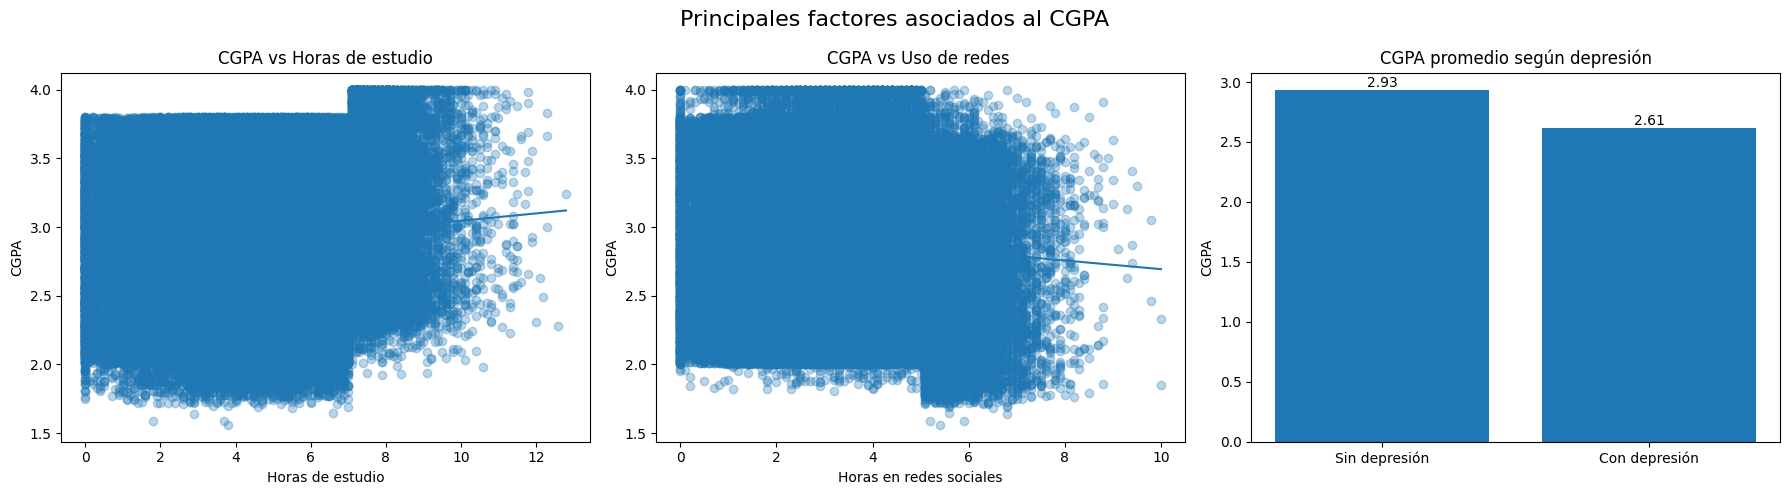

In [ ]:
# =========================
# 2) FIGURA EJECUTIVA (3 GRÁFICAS)
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =========================
# A) CGPA vs HORAS DE ESTUDIO
# =========================
x = df["Study_Hours"]
y = df["CGPA"]

axes[0].scatter(x, y, alpha=0.3)

# Línea de tendencia
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b
axes[0].plot(x_line, y_line)

r, p = stats.pearsonr(x, y)

axes[0].set_title(f"CGPA vs Horas de estudio")
axes[0].set_xlabel("Horas de estudio")
axes[0].set_ylabel("CGPA")

# =========================
# B) CGPA vs REDES SOCIALES
# =========================
x = df["Social_Media_Hours"]
y = df["CGPA"]

axes[1].scatter(x, y, alpha=0.3)

m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b
axes[1].plot(x_line, y_line)

r, p = stats.pearsonr(x, y)

axes[1].set_title(f"CGPA vs Uso de redes ")
axes[1].set_xlabel("Horas en redes sociales")
axes[1].set_ylabel("CGPA")

# =========================
# C) CGPA vs DEPRESIÓN
# =========================
means = df.groupby("Depression")["CGPA"].mean()
labels = ["Sin depresión", "Con depresión"]

axes[2].bar(labels, means.values)

for i, v in enumerate(means.values):
    axes[2].text(i, v, f"{v:.2f}", ha="center", va="bottom")

axes[2].set_title("CGPA promedio según depresión")
axes[2].set_ylabel("CGPA")

# =========================
# AJUSTE FINAL
# =========================
plt.suptitle("Principales factores asociados al CGPA", fontsize=16)
plt.tight_layout()
plt.show()

Concluye pregunta 1, tiempo de estudio, redes sociales y depresion son los maas influyentes para el CGPA (despemeño academico)

Pregunta 2: Relacion de estres y depresion con las demas variables

In [ ]:
# =========================
# 2) FUNCIONES AUXILIARES
# =========================
def cramers_v(x, y):
    """
    Cramér's V para asociación entre variables categóricas.
    """
    confusion = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    if n == 0:
        return np.nan
    r, k = confusion.shape
    phi2 = chi2 / n
    # Corrección opcional para tablas pequeñas
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return 0.0
    return np.sqrt(phi2corr / denom)

def eta_squared_anova(df, cat_var, num_var):
    """
    Tamaño de efecto eta^2 para ANOVA.
    """
    groups = [g[num_var].dropna().values for _, g in df.groupby(cat_var)]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) < 2:
        return np.nan, np.nan
    f_stat, p_val = stats.f_oneway(*groups)
    grand_mean = df[num_var].mean()
    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    ss_total = sum((df[num_var] - grand_mean) ** 2)
    eta2 = ss_between / ss_total if ss_total != 0 else np.nan
    return eta2, p_val

def point_biserial(df, num_var, binary_var):
    """
    Correlación point-biserial entre variable numérica y binaria.
    """
    x = df[num_var]
    y = df[binary_var]
    r, p = stats.pointbiserialr(y, x)
    return r, p

# =========================
# 3) VARIABLES EXPLICATIVAS
# =========================
targets = {
    "Stress_Level": "estrés",
    "Depression_num": "depresión"
}

# Excluir las variables objetivo del conjunto de predictores
predictors = [c for c in df.columns if c not in ["Stress_Level", "Depression", "Depression_num"]]

# Detectar tipos
numeric_predictors = [c for c in predictors if pd.api.types.is_numeric_dtype(df[c])]
categorical_predictors = [c for c in predictors if c not in numeric_predictors]

# =========================
# 4) FUNCIÓN PARA ANALIZAR UN OBJETIVO
# =========================
def analyze_target(df, target_col, target_type="numeric"):
    results = []

    # Variables numéricas -> asociación lineal
    for var in numeric_predictors:
        if var == target_col:
            continue
        if target_type == "numeric":
            r, p = stats.pearsonr(df[var], df[target_col])
            metric = abs(r)
            method = "Pearson |r|"
        else:
            r, p = point_biserial(df, var, target_col)
            metric = abs(r)
            method = "Point-biserial |r|"

        results.append({
            "Variable": var,
            "Tipo": "Numérica",
            "Método": method,
            "Métrica": metric,
            "p_value": p
        })

    # Variables categóricas -> ANOVA o Cramér's V
    for var in categorical_predictors:
        if var == target_col:
            continue

        if target_type == "numeric":
            eta2, p = eta_squared_anova(df, var, target_col)
            metric = eta2
            method = "Eta squared"
        else:
            v = cramers_v(df[var], df[target_col])
            # p-value por chi-cuadrado
            chi2, p, dof, exp = stats.chi2_contingency(pd.crosstab(df[var], df[target_col]))
            metric = v
            method = "Cramér's V"

        results.append({
            "Variable": var,
            "Tipo": "Categórica",
            "Método": method,
            "Métrica": metric,
            "p_value": p
        })

    res = pd.DataFrame(results).dropna()
    res = res.sort_values("Métrica", ascending=False).reset_index(drop=True)
    return res

# =========================
# 5) ANÁLISIS DE ESTRÉS
# =========================
stress_results = analyze_target(df, "Stress_Level", target_type="numeric")
print("\n=== Variables más asociadas al ESTRÉS ===")
print(stress_results.head(10).to_string(index=False))

# =========================
# 6) ANÁLISIS DE DEPRESIÓN
# =========================
depression_results = analyze_target(df, "Depression_num", target_type="binary")
print("\n=== Variables más asociadas a la DEPRESIÓN ===")
print(depression_results.head(10).to_string(index=False))

# =========================
# 7) RANKING COMBINADO
# =========================
combined = pd.merge(
    stress_results[["Variable", "Métrica"]].rename(columns={"Métrica": "Metrica_estres"}),
    depression_results[["Variable", "Métrica"]].rename(columns={"Métrica": "Metrica_depresion"}),
    on="Variable",
    how="outer"
)

# Rellenar con 0 cuando una variable no haya podido evaluarse por alguna razón
combined["Metrica_estres"] = combined["Metrica_estres"].fillna(0)
combined["Metrica_depresion"] = combined["Metrica_depresion"].fillna(0)

# Ranking dentro de cada objetivo
combined["Rank_estres"] = combined["Metrica_estres"].rank(ascending=False, method="min")
combined["Rank_depresion"] = combined["Metrica_depresion"].rank(ascending=False, method="min")

# Promedio de rangos para un ranking general
combined["Rank_promedio"] = (combined["Rank_estres"] + combined["Rank_depresion"]) / 2

combined = combined.sort_values(["Rank_promedio", "Rank_estres", "Rank_depresion"]).reset_index(drop=True)

print("\n=== Ranking combinado: variables más relacionadas con estrés y depresión ===")
print(combined.head(15).to_string(index=False))

# =========================
# 8) LISTA FINAL DE LAS MÁS IMPORTANTES
# =========================
top_stress = stress_results.head(5)["Variable"].tolist()
top_depression = depression_results.head(5)["Variable"].tolist()
top_combined = combined.head(5)["Variable"].tolist()

print("\nTop 5 por estrés:", top_stress)
print("Top 5 por depresión:", top_depression)
print("Top 5 combinadas:", top_combined)



=== Variables más asociadas al ESTRÉS ===
          Variable       Tipo      Método  Métrica  p_value
             Grupo Categórica Eta squared 0.640875 0.000000
      Stress_Group Categórica Eta squared 0.636498 0.000000
 Physical_Activity   Numérica Pearson |r| 0.296520 0.000000
    Sleep_Duration   Numérica Pearson |r| 0.281409 0.000000
              CGPA   Numérica Pearson |r| 0.012287 0.000102
       Study_Hours   Numérica Pearson |r| 0.008731 0.005760
        Student_ID   Numérica Pearson |r| 0.005230 0.098126
               Age   Numérica Pearson |r| 0.002999 0.342940
Social_Media_Hours   Numérica Pearson |r| 0.001941 0.539346
        Department Categórica Eta squared 0.000029 0.579996

=== Variables más asociadas a la DEPRESIÓN ===
          Variable       Tipo             Método  Métrica      p_value
             Grupo Categórica         Cramér's V 0.999990 0.000000e+00
              CGPA   Numérica Point-biserial |r| 0.178971 0.000000e+00
    Sleep_Duration   Numérica Point-

/tmp/ipykernel_9755/607576418.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden, rotation=30, ha="right")
/tmp/ipykernel_9755/607576418.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden, rotation=30, ha="right")
/tmp/ipykernel_9755/607576418.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden, rotation=30, ha="right")


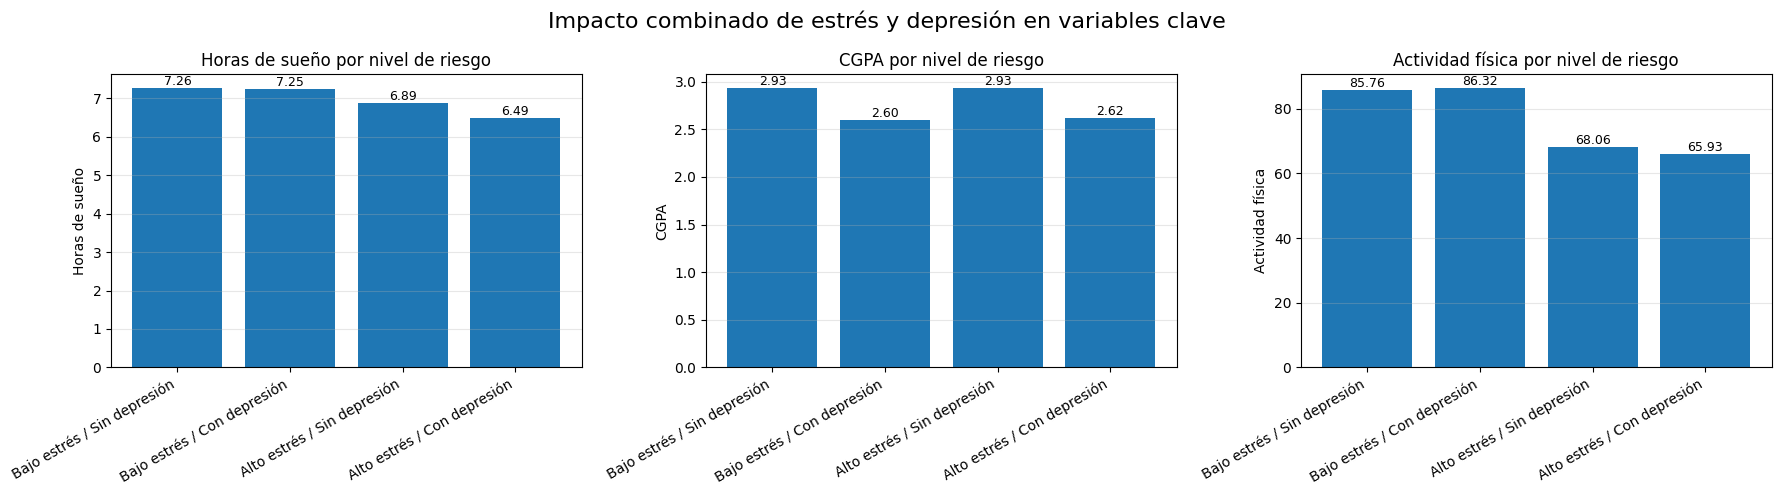

In [ ]:
# =========================
# 2) CREAR GRUPOS DE ESTRÉS
# =========================
# Definimos alto vs bajo estrés usando la mediana
stress_median = df["Stress_Level"].median()

df["Stress_Group"] = np.where(
    df["Stress_Level"] >= stress_median,
    "Alto estrés",
    "Bajo estrés"
)

# =========================
# 3) CREAR GRUPOS COMBINADOS
# =========================
df["Grupo"] = (
    df["Stress_Group"] + " / " +
    df["Depression"].map({False: "Sin depresión", True: "Con depresión"})
)

# Orden lógico para presentación
orden = [
    "Bajo estrés / Sin depresión",
    "Bajo estrés / Con depresión",
    "Alto estrés / Sin depresión",
    "Alto estrés / Con depresión"
]

# =========================
# 4) VARIABLES A ANALIZAR
# =========================
vars_analysis = {
    "Sleep_Duration": "Horas de sueño",
    "CGPA": "CGPA",
    "Physical_Activity": "Actividad física"
}

# =========================
# 5) GRAFICA EJECUTIVA
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (var, title) in zip(axes, vars_analysis.items()):

    means = df.groupby("Grupo")[var].mean().reindex(orden)

    ax.bar(orden, means.values)

    ax.set_title(f"{title} por nivel de riesgo")
    ax.set_ylabel(title)
    ax.set_xticklabels(orden, rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.3)

    # Etiquetas de valores
    for i, v in enumerate(means.values):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

# Título general
plt.suptitle("Impacto combinado de estrés y depresión en variables clave", fontsize=16)

plt.tight_layout()
plt.show()

Concluimos pregunta 2, con estres y depresion se ven mas afectadas las horas de sueño, actividad fisica y el desempeño academico

 Pregunta 3: ya vimos que la edad, genero o departamento no generan diferencian significativas en el bienestar

Pregunta 4: Los datos y la comparacion nos dice que si, podriamos decir que el CGPA es consecuencia y tomar las horas de sueño y actividad fisica como factores de proteccion

Pregunta 5: Si, es una variable que se ve afectada por las horas de estudio, ya que las mismas se reparten entre horas de estudio y uso de redes sociales, que podemos entender como tiempo libre del estudiante, sin embargo no podemos asegurar que el bajo desempeño genere depresion, podria ser al reves, que la depresion genere esos resultados, quedan fuera de alcance los datos sobre el inicio de la depresion y el CGPA antes y despues de la misma. Podriamos concluir por tanto que es una consecuencia

Pregunta 6: Basandonos en lo observado, podemos generar perfiles de reisgo con el patron de actividad fisica, estres, horas de sueño y CPGA para clasificar estos perfiles en grupos de riesgo y darles seguimiento

Hipotesis 1: Mayor estres implica mayor depresion


=== Resumen por nivel de estrés ===
   Stress_Level      n  depression_rate  depression_pct
0             2  13591         0.088514        8.851446
1             3  22666         0.090929        9.092914
2             4  23326         0.093972        9.397239
3             5  24525         0.094597        9.459735
4             6  11653         0.101004       10.100403
5             7   2255         0.122395       12.239468
6             8   1506         0.417663       41.766268
7             9    474         0.421941       42.194093
8            10      4         1.000000      100.000000

=== Correlación de Spearman ===
rho = 0.0509
p-value = 2.3000e-58

=== Chi-cuadrado ===
chi2 = 2327.8857
p-value = 0.0000e+00
grados de libertad = 8


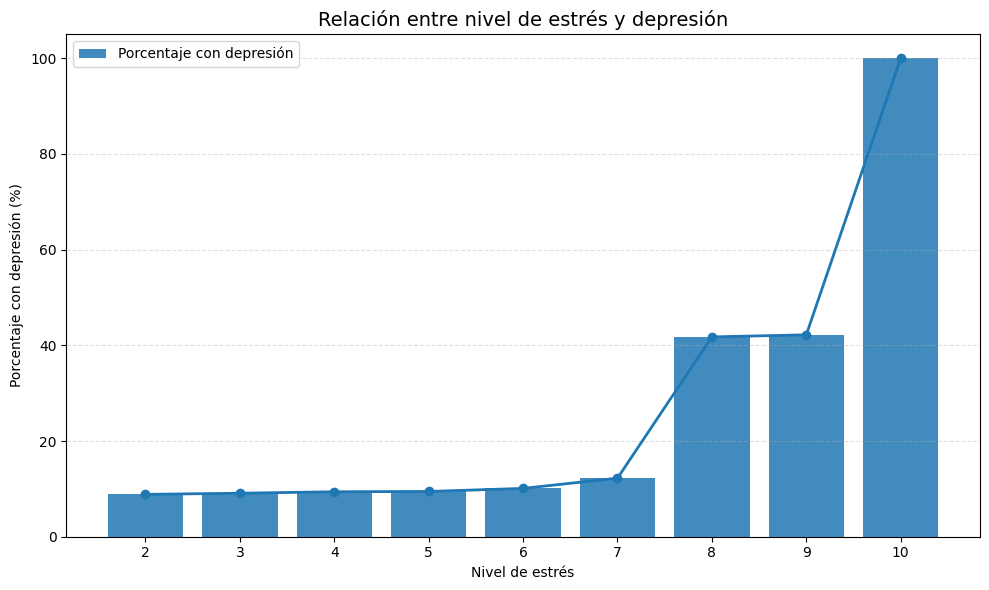

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, chi2_contingency

# =========================
# 1) Cargar la base de datos
# =========================
file_path = "student_lifestyle_100k.xlsx"   # cambia la ruta si hace falta
df = pd.read_excel(file_path)

# =========================================
# 2) Limpiar y convertir Depresión a binario
# =========================================
# En tu archivo, Depression viene como texto: 'True' / 'False'
df["Depression_bin"] = (
    df["Depression"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": 1, "false": 0})
)

# Eliminar filas con datos faltantes en las columnas clave
df = df.dropna(subset=["Stress_Level", "Depression_bin"])

# =========================================
# 3) Resumen por nivel de estrés
# =========================================
summary = (
    df.groupby("Stress_Level", as_index=False)
      .agg(
          n=("Depression_bin", "size"),
          depression_rate=("Depression_bin", "mean")
      )
)

summary["depression_pct"] = summary["depression_rate"] * 100

print("\n=== Resumen por nivel de estrés ===")
print(summary)

# =========================================
# 4) Correlación entre estrés y depresión
# =========================================
# Spearman es buena opción porque Stress_Level es ordinal
rho, p_value = spearmanr(df["Stress_Level"], df["Depression_bin"])

print("\n=== Correlación de Spearman ===")
print(f"rho = {rho:.4f}")
print(f"p-value = {p_value:.4e}")

# Prueba chi-cuadrado sobre tabla de contingencia
contingency = pd.crosstab(df["Stress_Level"], df["Depression_bin"])
chi2, p_chi, dof, expected = chi2_contingency(contingency)

print("\n=== Chi-cuadrado ===")
print(f"chi2 = {chi2:.4f}")
print(f"p-value = {p_chi:.4e}")
print(f"grados de libertad = {dof}")

# =========================================
# 5) Gráfica
# =========================================
plt.figure(figsize=(10, 6))

plt.bar(
    summary["Stress_Level"],
    summary["depression_pct"],
    alpha=0.85,
    label="Porcentaje con depresión"
)

plt.plot(
    summary["Stress_Level"],
    summary["depression_pct"],
    marker="o",
    linewidth=2
)

plt.title("Relación entre nivel de estrés y depresión", fontsize=14)
plt.xlabel("Nivel de estrés")
plt.ylabel("Porcentaje con depresión (%)")
plt.xticks(summary["Stress_Level"])
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

Hipotesis valida, la relacion es clara y directa, sirve como indicador

Hipotesis 2: Horas de sueño se aoscia con el CGPA

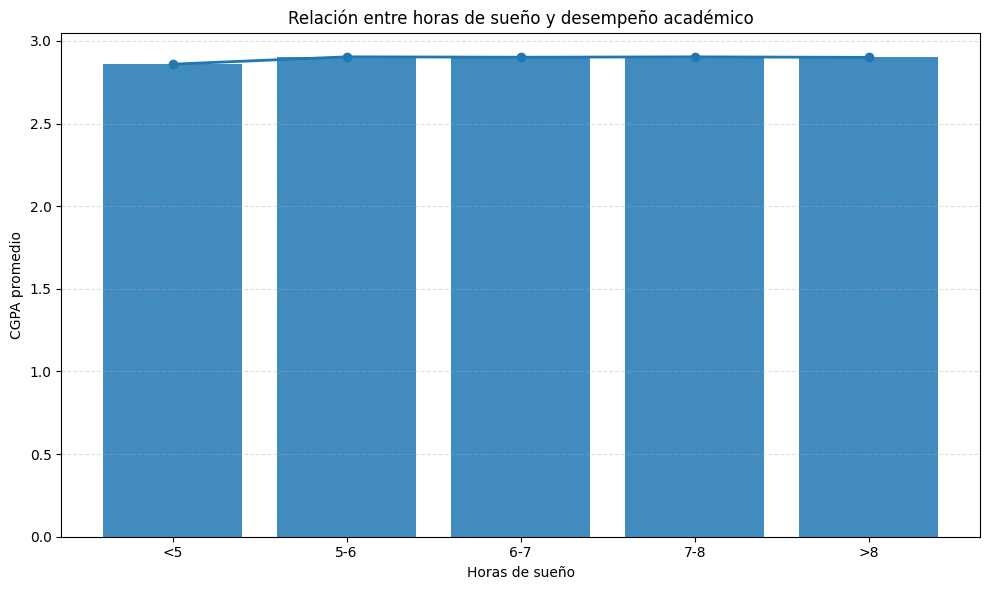

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm

# =========================
# 1) Cargar la base de datos
# =========================
file_path = "student_lifestyle_100k.xlsx"   # ajusta la ruta si hace falta
df = pd.read_excel(file_path)

# =========================================
# 2) Limpiar datos clave
# =========================================
df = df.dropna(subset=["Sleep_Duration", "CGPA"])

# =========================================
# 3) Resumen por intervalos de sueño
# =========================================
# Intervalos para comparar si dormir menos se asocia con menor CGPA
bins = [0, 5, 6, 7, 8, 20]
labels = ["<5", "5-6", "6-7", "7-8", ">8"]

df["Sleep_Bin"] = pd.cut(df["Sleep_Duration"], bins=bins, labels=labels, right=False)

summary = (
    df.groupby("Sleep_Bin", observed=True)
      .agg(
          n=("CGPA", "size"),
          promedio_cgpa=("CGPA", "mean"),
          mediana_cgpa=("CGPA", "median"),
          std_cgpa=("CGPA", "std")
      )
      .reset_index()
)

# =========================================
# 4) Correlaciones
# =========================================
rho_s, p_s = spearmanr(df["Sleep_Duration"], df["CGPA"])
r_p, p_p = pearsonr(df["Sleep_Duration"], df["CGPA"])

# =========================================
# 5) Regresión lineal simple
# =========================================
X = sm.add_constant(df["Sleep_Duration"])
model = sm.OLS(df["CGPA"], X).fit()

# =========================================
# 6) Gráfica 1: promedio de CGPA por rango de sueño
# =========================================
plt.figure(figsize=(10, 6))
plt.bar(summary["Sleep_Bin"].astype(str), summary["promedio_cgpa"], alpha=0.85)
plt.plot(summary["Sleep_Bin"].astype(str), summary["promedio_cgpa"], marker="o", linewidth=2)

plt.title("Relación entre horas de sueño y desempeño académico")
plt.xlabel("Horas de sueño")
plt.ylabel("CGPA promedio")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Concluimos que la hipotsis es falsa, no hay mucha relacion

Hipotesis 3: Mayor tiempo de estudio se relaciona con mayor CGPA, validamos hipotesis ya que lo vimos en el primer analisis de CGPA

Hipotesis 4: Mayor actividad fisica menor estres, verdadero, es de las variables con mayor relacion

Hipotesis 5: Diferencias significativas entre cada departamento en rendimiento y bienestar.


=== Resumen por departamento ===
    Department      n  cgpa_promedio  depresion_pct
0         Arts  19998       2.902723      10.151015
4      Science  20071       2.897992       9.949679
1     Business  19910       2.897674      10.185836
2  Engineering  20057       2.897135      10.071297
3      Medical  19964       2.896052       9.952915


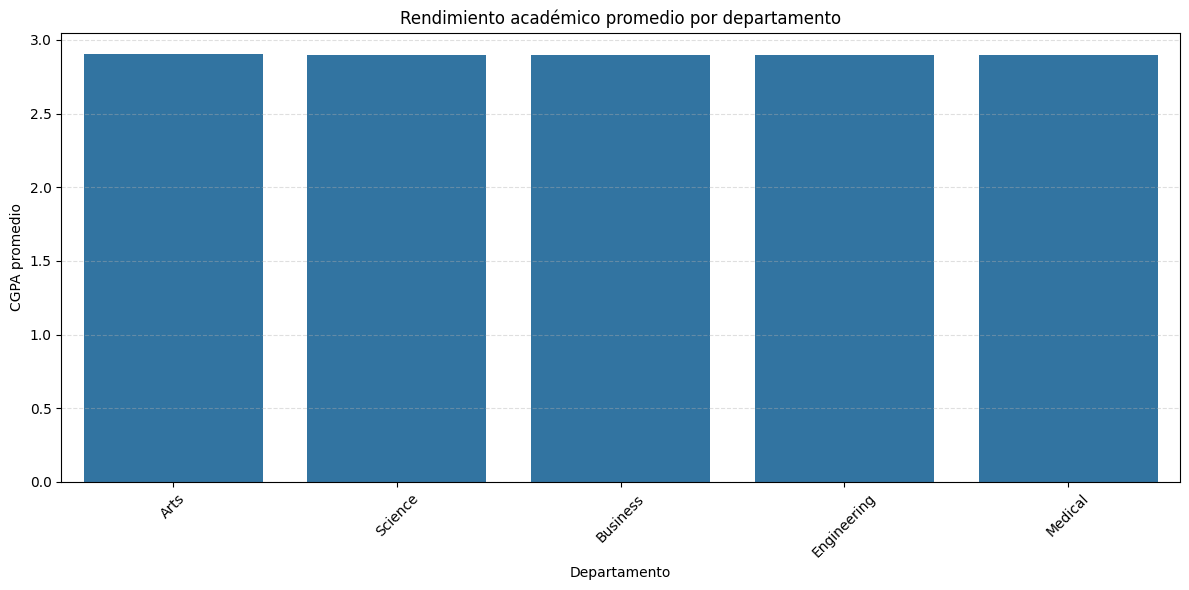

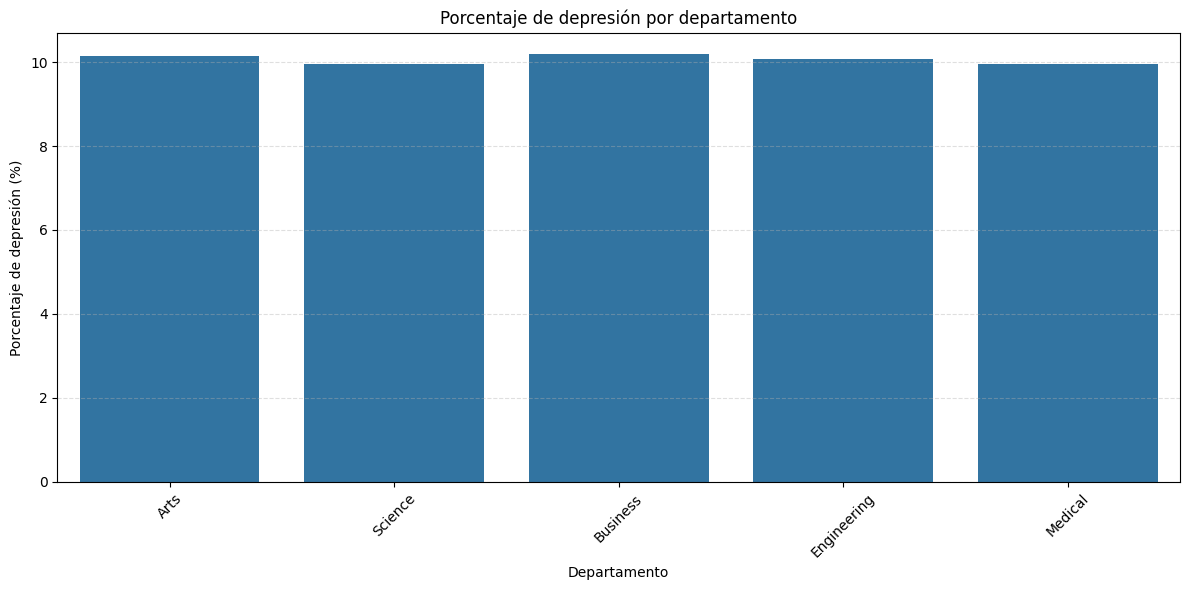


=== Tabla final ordenada ===
    Department      n  cgpa_promedio  depresion_pct
0         Arts  19998       2.902723      10.151015
4      Science  20071       2.897992       9.949679
1     Business  19910       2.897674      10.185836
2  Engineering  20057       2.897135      10.071297
3      Medical  19964       2.896052       9.952915


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1) Cargar la base
# =========================
file_path = "student_lifestyle_100k.xlsx"  # ajusta la ruta si hace falta
df = pd.read_excel(file_path)

# =========================
# 2) Limpieza básica
# =========================
df["Depression_bin"] = (
    df["Depression"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": 1, "false": 0})
)

df = df.dropna(subset=["Department", "CGPA", "Depression_bin"])

# =========================
# 3) Resumen por departamento
# =========================
summary = (
    df.groupby("Department", as_index=False)
      .agg(
          n=("Student_ID", "count"),
          cgpa_promedio=("CGPA", "mean"),
          depresion_pct=("Depression_bin", lambda x: x.mean() * 100)
      )
      .sort_values("cgpa_promedio", ascending=False)
)

print("\n=== Resumen por departamento ===")
print(summary)

# =========================
# 4) Gráfica 1: rendimiento académico
# =========================
plt.figure(figsize=(12, 6))
sns.barplot(data=summary, x="Department", y="cgpa_promedio")
plt.title("Rendimiento académico promedio por departamento")
plt.xlabel("Departamento")
plt.ylabel("CGPA promedio")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# =========================
# 5) Gráfica 2: porcentaje de depresión
# =========================
plt.figure(figsize=(12, 6))
sns.barplot(data=summary, x="Department", y="depresion_pct")
plt.title("Porcentaje de depresión por departamento")
plt.xlabel("Departamento")
plt.ylabel("Porcentaje de depresión (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# =========================
# 6) Tabla final ordenada
# =========================
print("\n=== Tabla final ordenada ===")
print(summary[["Department", "n", "cgpa_promedio", "depresion_pct"]])

No hay cambios significativos respecto a cada departamento


=== CGPA por combinación estudio + redes ===
   Study_Level Social_Level      n  cgpa_promedio
0         Bajo         Bajo   1586       2.904369
1         Bajo        Medio   4635       2.898360
2         Bajo         Alto   3328       2.827191
3         Bajo     Muy alto    517       2.715029
4        Medio         Bajo   7341       2.902302
5        Medio        Medio  23182       2.897364
6        Medio         Alto  15825       2.836565
7        Medio     Muy alto   2561       2.712968
8         Alto         Bajo   5520       2.957301
9         Alto        Medio  17059       2.940746
10        Alto         Alto  12280       2.890205
11        Alto     Muy alto   1887       2.734992
12    Muy alto         Bajo    637       3.169498
13    Muy alto        Medio   1944       3.187356
14    Muy alto         Alto   1482       3.142503
15    Muy alto     Muy alto    216       3.028843


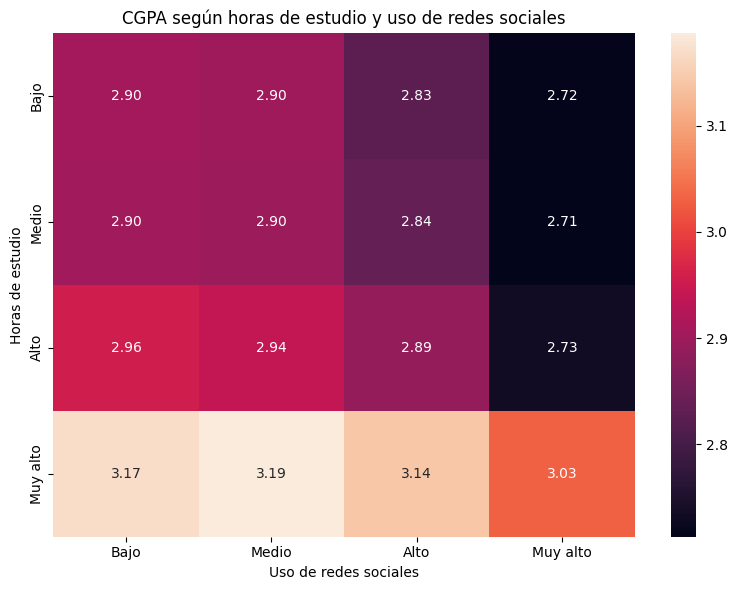

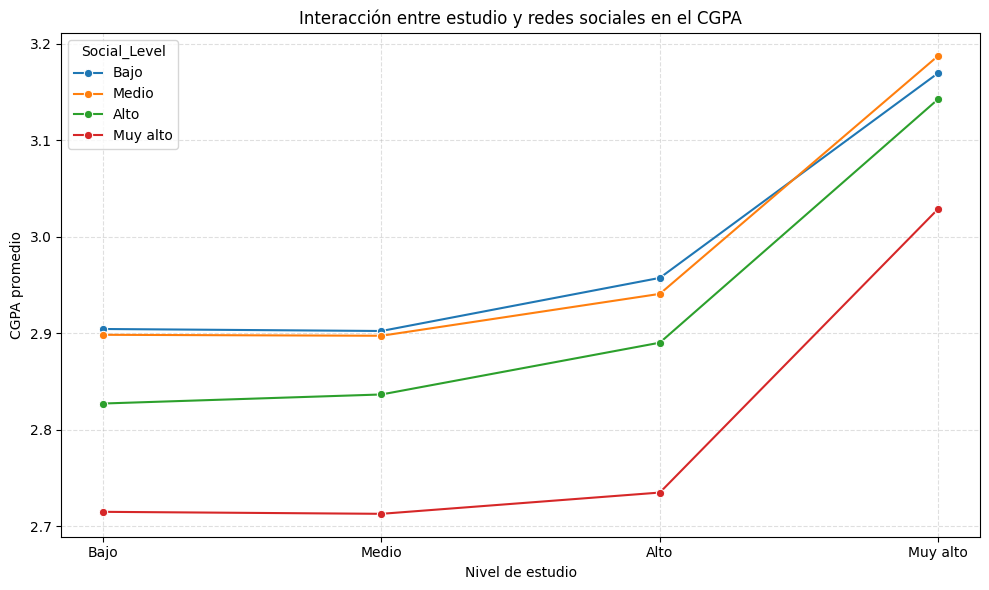

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1) Cargar datos
# =========================
file_path = "student_lifestyle_100k.xlsx"
df = pd.read_excel(file_path)

# =========================
# 2) Limpieza
# =========================
df = df.dropna(subset=["Study_Hours", "Social_Media_Hours", "CGPA"])

# =========================
# 3) Crear categorías (bins)
# =========================
# Estudio
study_bins = [0, 2, 5, 8, 15]
study_labels = ["Bajo", "Medio", "Alto", "Muy alto"]
df["Study_Level"] = pd.cut(df["Study_Hours"], bins=study_bins, labels=study_labels, right=False)

# Redes sociales
social_bins = [0, 2, 4, 6, 12]
social_labels = ["Bajo", "Medio", "Alto", "Muy alto"]
df["Social_Level"] = pd.cut(df["Social_Media_Hours"], bins=social_bins, labels=social_labels, right=False)

# =========================
# 4) Tabla combinada
# =========================
summary = (
    df.groupby(["Study_Level", "Social_Level"], observed=True)
      .agg(
          n=("CGPA", "count"),
          cgpa_promedio=("CGPA", "mean")
      )
      .reset_index()
)

print("\n=== CGPA por combinación estudio + redes ===")
print(summary)

# =========================
# 5) Heatmap (visual principal)
# =========================
pivot_table = summary.pivot(index="Study_Level", columns="Social_Level", values="cgpa_promedio")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f")

plt.title("CGPA según horas de estudio y uso de redes sociales")
plt.xlabel("Uso de redes sociales")
plt.ylabel("Horas de estudio")
plt.tight_layout()
plt.show()

# =========================
# 6) Gráfica alternativa (interacción)
# =========================
plt.figure(figsize=(10, 6))
sns.lineplot(data=summary, x="Study_Level", y="cgpa_promedio", hue="Social_Level", marker="o")

plt.title("Interacción entre estudio y redes sociales en el CGPA")
plt.xlabel("Nivel de estudio")
plt.ylabel("CGPA promedio")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

AUC del modelo: 0.6815
Umbral óptimo de riesgo: 0.5514

Matriz de confusión (con umbral óptimo):
[[16177  6308]
 [ 1019  1496]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9407    0.7195    0.8154     22485
           1     0.1917    0.5948    0.2900      2515

    accuracy                         0.7069     25000
   macro avg     0.5662    0.6571    0.5527     25000
weighted avg     0.8654    0.7069    0.7625     25000


=== Intervalos de riesgo propuestos ===
Protegido:           Risk_Prob < 0.402
Vigilancia:          0.402 <= Risk_Prob < 0.551
Intervención alta:   0.551 <= Risk_Prob < 0.750
Crítico:             Risk_Prob >= 0.750

=== Resumen de perfiles de riesgo ===
        Risk_Profile      n  risk_min  risk_max  risk_avg  depression_rate  \
2          Protegido  39390     0.130     0.402     0.303              5.1   
3         Vigilancia  29311     0.402     0.551     0.476              7.0   
1  Intervención alta  29667  

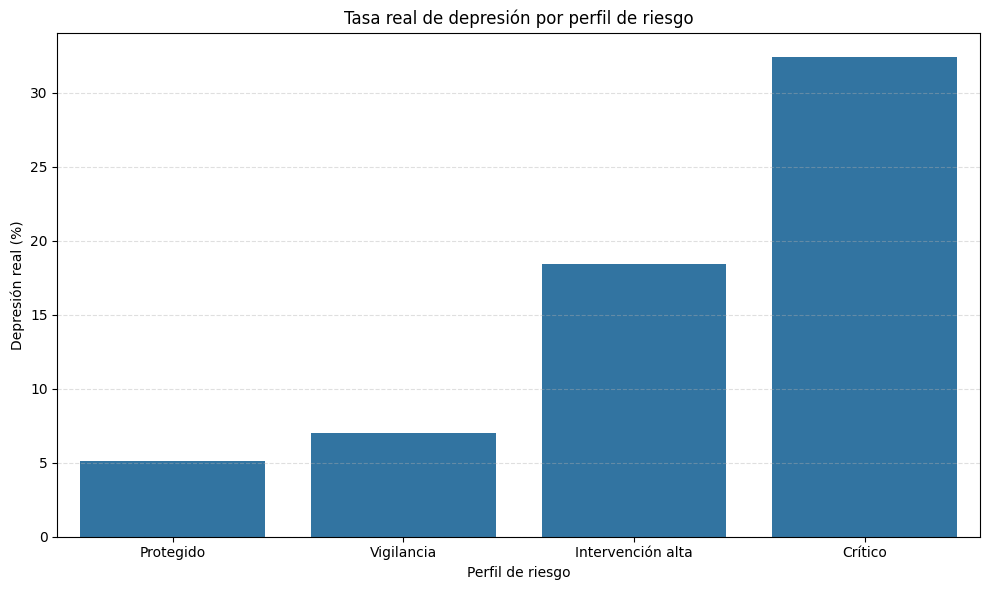

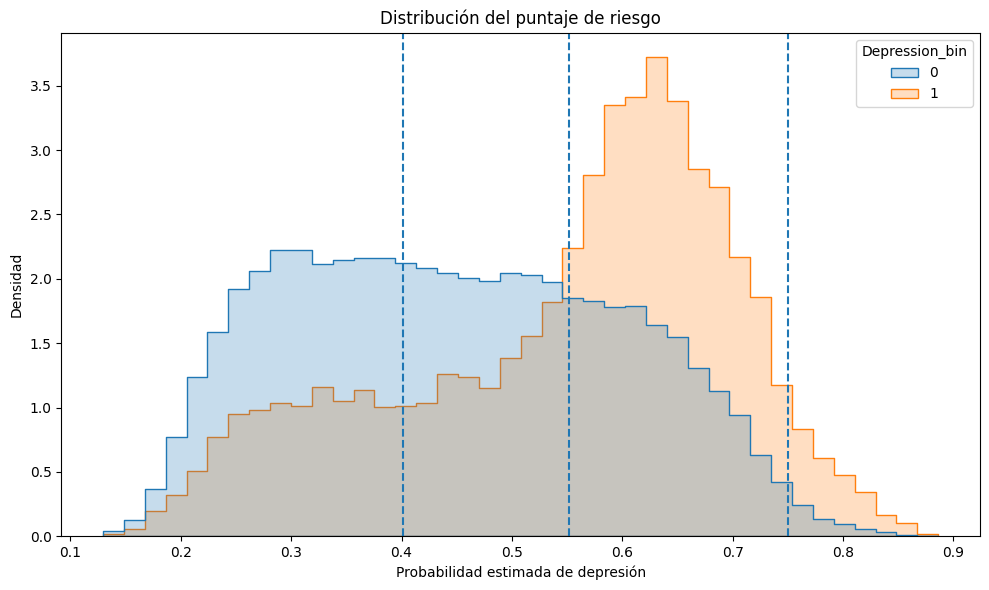


Archivo guardado: perfiles_riesgo_estudiantil.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

# =========================
# 1) Cargar datos
# =========================
file_path = "student_lifestyle_100k.xlsx"
df = pd.read_excel(file_path)

# =========================
# 2) Convertir depresión a binario
# =========================
df["Depression_bin"] = (
    df["Depression"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": 1, "false": 0})
)

# =========================
# 3) Variables para riesgo
#    (solo factores que ayudan a intervenir)
# =========================
features = [
    "CGPA",
    "Sleep_Duration",
    "Study_Hours",
    "Social_Media_Hours",
    "Physical_Activity",
    "Stress_Level"
]

data = df[features + ["Depression_bin"]].dropna().copy()

X = data[features]
y = data["Depression_bin"]

# =========================
# 4) Separar entrenamiento / prueba
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# =========================
# 5) Modelo de riesgo
# =========================
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

modelo.fit(X_train, y_train)

# Probabilidades en test para evaluar
proba_test = modelo.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba_test)

# Umbral óptimo por ROC (Youden J)
fpr, tpr, thresholds = roc_curve(y_test, proba_test)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
optimal_threshold = thresholds[best_idx]

print(f"AUC del modelo: {auc:.4f}")
print(f"Umbral óptimo de riesgo: {optimal_threshold:.4f}")
print("\nMatriz de confusión (con umbral óptimo):")
y_pred_test = (proba_test >= optimal_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_test))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_test, digits=4))

# =========================
# 6) Puntaje de riesgo para todo el dataset
# =========================
# Se usa el modelo entrenado para asignar probabilidad a cada alumno
data["Risk_Prob"] = modelo.predict_proba(X)[:, 1]

# =========================
# 7) Intervalo de intervención temprana
# =========================
# Límite inferior: el percentil 20 del riesgo entre alumnos con depresión real
# Eso marca el punto donde ya empieza a aparecer una señal relevante.
depressed_probs = data.loc[data["Depression_bin"] == 1, "Risk_Prob"]
alert_floor = float(np.quantile(depressed_probs, 0.20))

# Intervalos de perfil de riesgo
# - Protegido: muy baja probabilidad
# - Vigilancia: ya conviene observar y hacer seguimiento
# - Intervención prioritaria: riesgo alto
# - Crítico: riesgo muy alto
critical_floor = 0.75

print("\n=== Intervalos de riesgo propuestos ===")
print(f"Protegido:           Risk_Prob < {alert_floor:.3f}")
print(f"Vigilancia:          {alert_floor:.3f} <= Risk_Prob < {optimal_threshold:.3f}")
print(f"Intervención alta:   {optimal_threshold:.3f} <= Risk_Prob < {critical_floor:.3f}")
print(f"Crítico:             Risk_Prob >= {critical_floor:.3f}")

# =========================
# 8) Clasificar perfiles
# =========================
def risk_profile(p):
    if p < alert_floor:
        return "Protegido"
    elif p < optimal_threshold:
        return "Vigilancia"
    elif p < critical_floor:
        return "Intervención alta"
    else:
        return "Crítico"

data["Risk_Profile"] = data["Risk_Prob"].apply(risk_profile)

# =========================
# 9) Resumen de perfiles
# =========================
summary = (
    data.groupby("Risk_Profile", as_index=False)
        .agg(
            n=("Risk_Prob", "size"),
            risk_min=("Risk_Prob", "min"),
            risk_max=("Risk_Prob", "max"),
            risk_avg=("Risk_Prob", "mean"),
            depression_rate=("Depression_bin", "mean"),
            cgpa_avg=("CGPA", "mean"),
            sleep_avg=("Sleep_Duration", "mean"),
            study_avg=("Study_Hours", "mean"),
            social_avg=("Social_Media_Hours", "mean"),
            stress_avg=("Stress_Level", "mean"),
            activity_avg=("Physical_Activity", "mean")
        )
)

# Ordenar perfiles de menor a mayor riesgo
order = ["Protegido", "Vigilancia", "Intervención alta", "Crítico"]
summary["Risk_Profile"] = pd.Categorical(summary["Risk_Profile"], categories=order, ordered=True)
summary = summary.sort_values("Risk_Profile")

# Formato bonito para impresión
summary_print = summary.copy()
for col in ["risk_min", "risk_max", "risk_avg", "depression_rate", "cgpa_avg", "sleep_avg", "study_avg", "social_avg", "stress_avg", "activity_avg"]:
    summary_print[col] = summary_print[col].round(3)

summary_print["depression_rate"] = (summary_print["depression_rate"] * 100).round(2)

print("\n=== Resumen de perfiles de riesgo ===")
print(summary_print)

# =========================
# 10) Gráfica 1: proporción real de depresión por perfil
# =========================
plt.figure(figsize=(10, 6))
plot_df = summary.copy()
plot_df["depression_rate_pct"] = plot_df["depression_rate"] * 100

sns.barplot(data=plot_df, x="Risk_Profile", y="depression_rate_pct", order=order)
plt.title("Tasa real de depresión por perfil de riesgo")
plt.xlabel("Perfil de riesgo")
plt.ylabel("Depresión real (%)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# =========================
# 11) Gráfica 2: distribución del puntaje de riesgo
# =========================
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x="Risk_Prob", hue="Depression_bin", bins=40, element="step", stat="density", common_norm=False)
plt.axvline(alert_floor, linestyle="--")
plt.axvline(optimal_threshold, linestyle="--")
plt.axvline(critical_floor, linestyle="--")
plt.title("Distribución del puntaje de riesgo")
plt.xlabel("Probabilidad estimada de depresión")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

# =========================
# 12) Guardar resultados
# =========================
data[["CGPA", "Sleep_Duration", "Study_Hours", "Social_Media_Hours",
      "Physical_Activity", "Stress_Level", "Depression_bin",
      "Risk_Prob", "Risk_Profile"]].to_csv("perfiles_riesgo_estudiantil.csv", index=False)

print("\nArchivo guardado: perfiles_riesgo_estudiantil.csv")

La segunda grafica solo es para ver si si estan bien hechos los bloques